In [110]:
using PyPlot
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [111]:
function compute_Ω(I, γ, ω)
    return (6π*ustrip(c_0)^2*γ .* I / (ω^3 * ustrip(ħ))).^(1/2)
end

function decay_rate_indep(N, γ, Ω)
    return γ*N ./ (2 .+ (γ ./ Ω).^2)
end

decay_rate_indep (generic function with 1 method)

In [144]:
N_atoms_per_droplet = 15000
γ = 32.7e6 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
I_inc = [0.01:0.01:10;].*1e-3 # Intensity of the laser in W
sat = [0:100;]
Isat = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)
Ω = compute_Ω(I_inc, γ, ω0);
Ω_range_norm = Ω./γ;

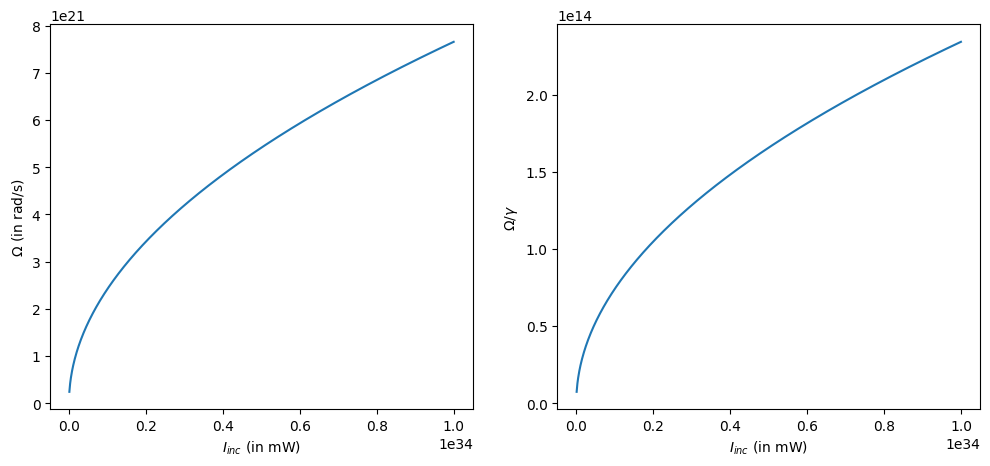

In [113]:
close("all")
figure, axs = subplots(1, 2, figsize=(12, 5))
axs[1].plot(I_inc.*1e3, Ω)
axs[1].set_xlabel(L"$I_{inc}$ (in mW)")
axs[1].set_ylabel(L"$\Omega$ (in rad/s)")

axs[2].plot(I_inc.*1e3, Ω_range_norm)
axs[2].set_xlabel(L"$I_{inc}$ (in mW)")
axs[2].set_ylabel(L"\Omega/\gamma")
pygui(false); gcf()

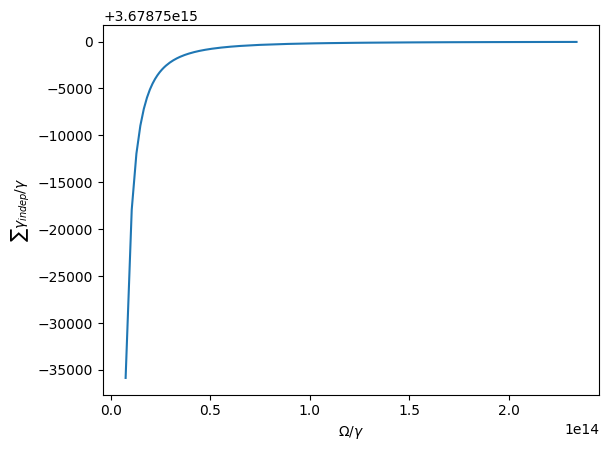

In [115]:
close("all")
figure = subplots()
plot(Ω_range_norm, N_atoms_per_droplet.*decay_rate_indep(N_atoms_per_droplet, γ, Ω_range_norm))
xlabel(L"\Omega/\gamma")
ylabel(L"\sum\gamma_{indep}/\gamma")
pygui(false); gcf()

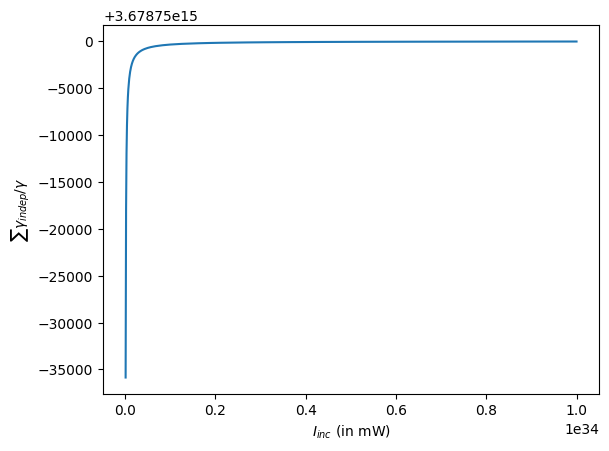

In [116]:
close("all")
figure = subplots()
plot(I_inc*1e3, N_atoms_per_droplet.*decay_rate_indep(N_atoms_per_droplet, γ, Ω_range_norm))
xlabel(L"$I_{inc}$ (in mW)")
ylabel(L"\sum\gamma_{indep}/\gamma")
pygui(false); gcf()

In [ ]:
function decay_atoms_indep_V2(I, γ, ω0)
    return 1 ./ (2 .+ γ*ω0^3*ustrip(ħ) ./ (6π*ustrip(c_0)^2 .*I))
end

decay_atoms_indep_V2 (generic function with 1 method)

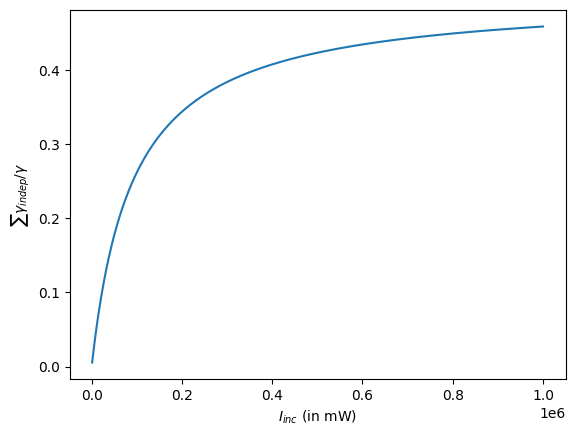

In [129]:
I_test = [1:1000;]

close("all")
figure = subplots()
plot(I_test.*1e3, decay_atoms_indep_V2(I_test, γ, ω0))
xlabel(L"$I_{inc}$ (in mW)")
ylabel(L"\sum\gamma_{indep}/\gamma")
pygui(false); gcf()

In [127]:
γ*ω0^3*ustrip(ħ) ./ (6π*ustrip(c_0)^2 )

182.3210490930527

In [150]:
function decay_atoms_indep_V3(sat)
    return 1/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep_V3 (generic function with 1 method)

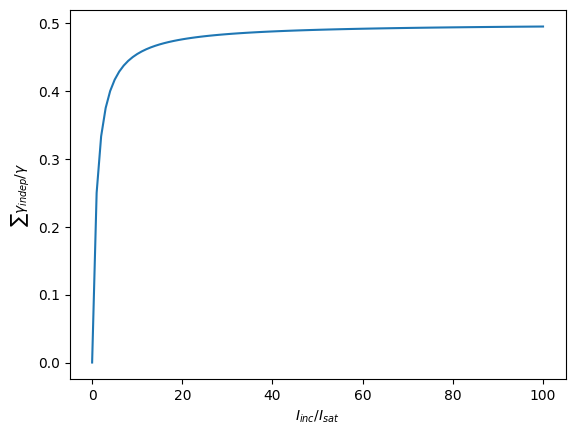

In [151]:
close("all")
figure = subplots()
plot(sat, decay_atoms_indep_V3(sat))
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\sum\gamma_{indep}/\gamma")
pygui(false); gcf()